In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

import spikeinterface as si
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
from probeinterface import get_probe, write_probeinterface

from format_waveform_data import map_contacts_simple

In [2]:
''' File paths '''
root_dir = "C:/Users/Isabel/Documents/data_temp/"

# session params
bird_id = "ROS107"
session_id = "260921"
ephys_id = "ROS107_260921_120030"
map_file = 'H15_128Chan_IntanMap.xlsx'
cmr = False

# path to .rhd intan file
intan_folder = f"{root_dir}{bird_id}_{session_id}/{ephys_id}/"

# probe map
map_file_path = f'Z:/Isabel/ephys/channel_maps/{map_file}'

# to save files
sort_dir = f"{intan_folder}/bombcell/"

In [3]:
''' load the recording and get params '''
recording = se.read_intan(f"{intan_folder}info.rhd", stream_id='0')
fs = recording.get_sampling_frequency()

In [4]:
''' get probe contact sort '''
contact_sort, ch_names, shank_idx = map_contacts_simple(map_file_path)

In [5]:
ch_names_sorted = []
for c in contact_sort:
    ch_names_sorted.append(ch_names[c])

In [6]:
bad_idx = np.asarray([57, 72]).astype(int) - 1
bad_ch = []
for b in bad_idx:
    bad_ch.append(ch_names_sorted[b])

bad_idx_sorted = []
for bad in bad_ch:
    bad_idx_sorted.append(ch_names.index(bad))
bad_idx_sorted = np.asarray(bad_idx_sorted).astype(int)

In [7]:
for bs, b in zip(bad_idx_sorted, bad_idx):
    print(ch_names[bs])
    print(ch_names_sorted[b])

for i, ch in enumerate(ch_names):
    print(f'{ch}, index {i}')

A-38-2
A-38-2
B-08-2
B-08-2
B-16-2, index 0
B-15-1, index 1
B-14-2, index 2
B-13-1, index 3
B-12-2, index 4
B-11-1, index 5
B-10-2, index 6
B-09-1, index 7
B-08-2, index 8
B-07-1, index 9
B-06-2, index 10
B-05-1, index 11
B-04-2, index 12
B-03-1, index 13
B-02-2, index 14
B-01-1, index 15
B-34-2, index 16
B-32-2, index 17
B-30-2, index 18
B-29-1, index 19
B-28-2, index 20
B-27-1, index 21
B-26-2, index 22
B-25-1, index 23
B-24-2, index 24
B-23-1, index 25
B-22-2, index 26
B-21-1, index 27
B-20-2, index 28
B-19-1, index 29
B-18-2, index 30
B-17-1, index 31
B-31-1, index 32
B-64-2, index 33
B-62-2, index 34
B-60-2, index 35
B-58-2, index 36
B-56-2, index 37
B-54-2, index 38
B-52-2, index 39
B-50-2, index 40
B-48-2, index 41
B-46-2, index 42
B-44-2, index 43
B-42-2, index 44
B-40-2, index 45
B-38-2, index 46
B-36-2, index 47
B-63-1, index 48
B-61-1, index 49
B-59-1, index 50
B-57-1, index 51
B-55-1, index 52
B-53-1, index 53
B-51-1, index 54
B-49-1, index 55
B-47-1, index 56
B-45-1, index

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

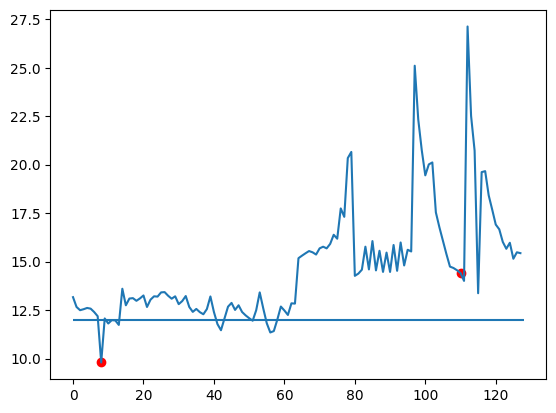

In [9]:
''' find and exclude noisy channels '''
noise_level = si.get_noise_levels(spre.common_reference(spre.highpass_filter(recording)))
plt.plot(noise_level)
plt.scatter(bad_idx_sorted, noise_level[bad_idx_sorted], c='r')
plt.hlines(12, 0, 128)

In [29]:
# set noise threshold and remove noisy channels
n_channels = len(ch_names)
all_ch_idx = np.arange(n_channels)
noise_thresh = 11
keep_ch_idx = noise_level > noise_thresh
bad_channel_idx = all_ch_idx[~keep_ch_idx]

print(f"excluding {np.sum(~keep_ch_idx)} channel(s)")

excluding 72 channel(s)


In [18]:
bad_channel_idx = bad_idx_sorted

In [30]:
np.sort(bad_channel_idx)

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  73,
        74,  75,  76,  77,  94, 102, 103])

In [12]:
# check the gain
gains = recording.get_channel_gains()
assert np.allclose(gains, gains[0]), "expected uniform gain across channels"
gain_to_uV = float(gains[0])   # typically 0.195 for Intan RHD-based systems
print()

In [13]:
# common median reference if needed
if cmr:
    rec_cmr = spre.common_reference(recording, reference="global", operator="median")
else:
    rec_cmr = recording

In [14]:
# to save files
sort_dir = f"{intan_folder}/bombcell/"

In [31]:
bad_channel_string = ''
for b_idx in bad_channel_idx:
    bad_channel_string = bad_channel_string + f'{b_idx}, '

print(f"Binary save path: {sort_dir}/traces_cached_seg0.raw")
print(f"Channel index to exlude: [{bad_channel_string}], fs: {fs}, gain_to_uV: {gain_to_uV}")

Binary save path: C:/Users/Isabel/Documents/data_temp/LMN86_260902/LMN86_260902_111350//bombcell//traces_cached_seg0.raw
Channel index to exlude: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 73, 74, 75, 76, 77, 94, 102, 103, ], fs: 30000.0, gain_to_uV: 0.195


In [ ]:
# save as binary for KS4 and BC
rec_cmr.save(format="binary", folder=sort_dir, dtype="int16", 
             n_jobs=8, chunk_duration="1s")